<a href="https://colab.research.google.com/github/dhu33/Smart-Inventory-Management/blob/main/Smart_Inventory_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
class Product ():
    def __init__ (self,name,price,quantity):
        self.name=name
        self.price=price
        self.quantity=quantity
    def totalvalue(self):

        sum=self.price*self.quantity
        print(sum)
    def printer(self):
        print(self.name,self.price,self.quantity)


p=[]
p.append(Product('sale',1000,5))
p.append(Product('dddd',2000,7))
def client(p=[]):
       x=int(input('ادخل رقم المنتج '))
       name_p=input('enter the nameof the proudecr')
       quantityp=int(input('how many'))


       if((name_p==p[x].name) and (quantityp<=p[x].quantity)):

              print('تم البيع ')
              p[x].quantity-=quantityp
              print(p[x].quantity)

       else:
              print('خلصت الكميه او المنتج غير متاح ')


def reportr(p=[]):
        count=0
        while(count<len(p)):
           p[count].printer()
           count+=1
# reportr(p)
# client(p)

sale 1000 5
dddd 2000 7
ادخل رقم المنتج 0


In [ ]:
reportr(p)

In [ ]:
client(p)

In [ ]:
reportr(p)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random as rand
import os
import sklearn
from sklearn import datasets,model_selection,linear_model,metrics,preprocessing,neighbors,tree,ensemble
import tensorflow as tf

In [9]:
s=pd.read_csv('/content/stores_sales_forecasting.csv',encoding='latin1')
s.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2121 non-null   int64  
 1   Order ID       2121 non-null   object 
 2   Order Date     2121 non-null   object 
 3   Ship Date      2121 non-null   object 
 4   Ship Mode      2121 non-null   object 
 5   Customer ID    2121 non-null   object 
 6   Customer Name  2121 non-null   object 
 7   Segment        2121 non-null   object 
 8   Country        2121 non-null   object 
 9   City           2121 non-null   object 
 10  State          2121 non-null   object 
 11  Postal Code    2121 non-null   int64  
 12  Region         2121 non-null   object 
 13  Product ID     2121 non-null   object 
 14  Category       2121 non-null   object 
 15  Sub-Category   2121 non-null   object 
 16  Product Name   2121 non-null   object 
 17  Sales          2121 non-null   float64
 18  Quantity

In [10]:
s[['Sales', 'Quantity']]

,Sales,Quantity
0,261.9600,2
1,731.9400,3
2,957.5775,5
3,48.8600,7
4,1706.1840,9
...,...,...
2116,383.4656,4
2117,13.4000,1
2118,85.9800,1
2119,25.2480,3


In [11]:

daily_sales = s.groupby('Order Date')[['Sales', 'Profit']].sum().reset_index()
print("--- سجل المبيعات اليومي المجمع بنجاح ---")
print(daily_sales.head())

--- سجل المبيعات اليومي المجمع بنجاح ---
  Order Date     Sales    Profit
0   1/1/2017   975.490   -6.1993
1  1/10/2014    51.940   21.2954
2  1/10/2015  1018.104 -373.3048
3  1/10/2016   104.770   42.0691
4  1/11/2014     9.940    3.0814


In [12]:
daily_sales['Day_Index'] = range(1, len(daily_sales) + 1)
print("--- الجدول بعد إضافة عمود الأرقام التسلسلية للذكاء الاصطناعي ---")
print(daily_sales[['Day_Index', 'Order Date', 'Sales']].head())

--- الجدول بعد إضافة عمود الأرقام التسلسلية للذكاء الاصطناعي ---
   Day_Index Order Date     Sales
0          1   1/1/2017   975.490
1          2  1/10/2014    51.940
2          3  1/10/2015  1018.104
3          4  1/10/2016   104.770
4          5  1/11/2014     9.940


In [13]:
# 1. فصل المدخلات والمستهدف من الجدول المجمع الصحيح
X = daily_sales[['Day_Index']]  # أبقيناها بأقواس مزدوجة لتكون ثنائية الأبعاد
y = daily_sales['Sales'].values

# 2. تقييس البيانات (الـ Normalization المأخوذ من كودكِ)
x_normalize = preprocessing.StandardScaler()
x_norm = x_normalize.fit_transform(X)

y_normalize = preprocessing.MinMaxScaler()
y_norm = y_normalize.fit_transform(y.reshape(-1, 1))

# 3. تقسيم البيانات إلى تدريب واختبار
x_train, x_test, y_train, y_test = model_selection.train_test_split(
    x_norm, y_norm, test_size=0.1, random_state=42
)

# 4. بناء وتدريب نموذج الـ Linear Regression والتنبؤ
r = linear_model.LinearRegression()
r.fit(x_train, y_train)
y_pre = r.predict(x_test)

# 5. طباعة متوسط الخطأ المطلق للنموذج
print("متوسط الخطأ المطلق (MAE) لنموذج التنبؤ بالمبيعات هو:")
print(metrics.mean_absolute_error(y_pre, y_test))

متوسط الخطأ المطلق (MAE) لنموذج التنبؤ بالمبيعات هو:
0.07230727781824951


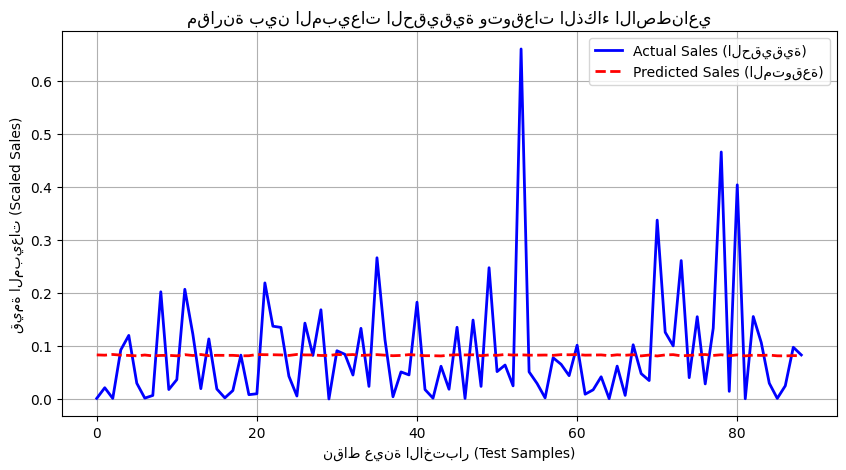

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(y_test, label='Actual Sales (الحقيقية)', color='blue', linewidth=2)
plt.plot(y_pre, label='Predicted Sales (المتوقعة)', color='red', linestyle='--', linewidth=2)
plt.title('مقارنة بين المبيعات الحقيقية وتوقعات الذكاء الاصطناعي')
plt.xlabel('نقاط عينة الاختبار (Test Samples)')
plt.ylabel('قيمة المبيعات (Scaled Sales)')
plt.legend()
plt.grid(True)